### Importación de librerías

Importamos las librerías a utilizar

In [119]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
import faiss
import os
import wget
import google.generativeai as genai
import ast
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from wordcloud import WordCloud
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
import unicodedata
from dotenv import load_dotenv
import joblib

### Configuración del dataset y modelo

- Descarga y preparación del dataset de películas.
- Configura el modelode Gemini con la API.

In [120]:
# --- Configuración del dataset de películas ---
DATASET_DOWNLOAD_URL = "https://www.kaggle.com/api/v1/datasets/download/utkarshx27/movies-dataset"
DATASET_FILE_NAME = "movies-dataset.zip"
DATASET_CSV_NAME = "movie_dataset.csv"
DATASET_DIR = "./data/"
DATASET_LOCAL_PATH = os.path.join(DATASET_DIR, DATASET_CSV_NAME)

# --- Configuración de la API de Gemini ---
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")


# Configurar la API de Google Gemini
genai.configure(api_key=GEMINI_API_KEY)

# Listamos los modelos disponibles (lo usamos para debug)
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

# Seleccionamos el modelo geminio que vamos a usar
GEMINI_MODEL_NAME = "gemma-3-27b-it"

try:
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    print(f"Modelo Gemini '{GEMINI_MODEL_NAME}' configurado exitosamente.")
except Exception as e:
    print(f"Error al configurar el modelo Gemini: {e}")
    print("Por favor, verifica tu clave API y tu conexión a internet.")
    raise

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025
Modelo Gemini 'gemma-3-27b-it' configurado e

### Descarga dataset

In [121]:
# Crea la carpeta de datos si no existe
os.makedirs(DATASET_DIR, exist_ok=True)

# Descarga el dataset si no existe localmente
if not os.path.exists(DATASET_LOCAL_PATH):
    print(f"Descargando el dataset de películas (aprox. 23 MB) a: {DATASET_DIR}")
    print("Esto puede tardar unos segundos...")
    try:
        # wget descarga el zip, luego lo descomprimimos
        zip_path = os.path.join(DATASET_DIR, DATASET_FILE_NAME)
        wget.download(DATASET_DOWNLOAD_URL, out=zip_path)
        print("\nDescarga del ZIP completada. Descomprimiendo...")

        import zipfile
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extract(DATASET_CSV_NAME, DATASET_DIR)
        os.remove(zip_path) # Elimina el zip después de descomprimir
        print(f"Dataset '{DATASET_CSV_NAME}' descomprimido.")

    except Exception as e:
        print(f"\nError al descargar o descomprimir el dataset: {e}")
        raise

print(f"Cargando el dataset desde: {DATASET_LOCAL_PATH}")
movies_df = pd.read_csv(DATASET_LOCAL_PATH)
print("Dataset cargado exitosamente.")
print(movies_df.columns)

Cargando el dataset desde: ./data/movie_dataset.csv
Dataset cargado exitosamente.
Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='str')


### Preprocesamiento

- Renombra columnas.
- Parsea y aplica las columnas de género y actores.
- Realiza la traducción de los géneros.
- Combina el texto para llevarlo a un embedding.
- Elimina duplicados.

In [122]:
# --- Preprocesamiento del dataset ---
movies_df.rename(columns={'title': 'CleanTitle'}, inplace=True)

movies_df.loc[:, 'Year'] = pd.to_datetime(movies_df['release_date'], errors='coerce').dt.year
movies_df['Year'] = movies_df['Year'].astype('Int64')

# --- Funciones de parsing ---
def parse_genres_robust(genres_str):
    if pd.isna(genres_str) or genres_str == '[]' or genres_str == '':
        return []
    try:
        genres_list = ast.literal_eval(genres_str)
        if isinstance(genres_list, list):
            return [d['name'] for d in genres_list if isinstance(d, dict) and 'name' in d]
        else:
            raise ValueError("Not a list of dictionaries")
    except (ValueError, SyntaxError):
        if ',' in genres_str:
            return [g.strip() for g in genres_str.split(',') if g.strip()]
        else:
            return [g.strip() for g in genres_str.split(' ') if g.strip()]
    except Exception as e:
        print(f"Advertencia al parsear géneros: {e}")
        return []

def parse_cast_robust(cast_str):
    if pd.isna(cast_str) or cast_str == '[]' or cast_str == '':
        return []
    try:
        cast_list = ast.literal_eval(cast_str)
        if isinstance(cast_list, list):
            return [d['name'] for d in cast_list if isinstance(d, dict) and 'name' in d]
        else:
            raise ValueError("Not a list of dictionaries")
    except (ValueError, SyntaxError):
        if ',' in cast_str:
            return [c.strip() for c in cast_str.split(',') if c.strip()]
        else:
            return [cast_str.strip()]

# Aplica funciones de parsing
movies_df['genres_parsed'] = movies_df['genres'].apply(parse_genres_robust)

# Traducción de géneros del inglés al español
genre_translation = {
    "Action": "Acción",
    "Adventure": "Aventura",
    "Comedy": "Comedia",
    "Drama": "Drama",
    "Science Fiction": "Ciencia Ficción",
    "Horror": "Terror",
    "Thriller": "Thriller",
    "Romance": "Romance",
    "Animation": "Animación",
    "Documentary": "Documental",
    "Mystery": "Misterio",
    "Fantasy": "Fantasía",
    "Crime": "Crimen"
}

def traducir_generos(generos):
    return [genre_translation.get(g, g) for g in generos]

movies_df['genres_traducidos'] = movies_df['genres_parsed'].apply(traducir_generos)
movies_df['Genres'] = movies_df['genres_traducidos'].apply(lambda x: ', '.join(x) if x else '')

movies_df['cast_parsed'] = movies_df['cast'].apply(parse_cast_robust)
movies_df['CleanCast'] = movies_df['cast_parsed'].apply(lambda x: ', '.join(x) if x else '')

movies_df.rename(columns={'vote_average': 'AvgRating'}, inplace=True)

# Texto combinado para embeddings
movies_df['combined_text'] = (
    "Título: " + movies_df['CleanTitle'].fillna('') + ". " +
    "Año: " + movies_df['Year'].astype(str).fillna('') + ". " +
    "Géneros: " + movies_df['Genres'].fillna('') + ". " +
    "Actores: " + movies_df['CleanCast'].fillna('') + ". " +
    "Sinopsis: " + movies_df['overview'].fillna('')
)

# Elimina duplicados
movies_df.drop_duplicates(subset=['CleanTitle', 'Year'], inplace=True, ignore_index=True)

print(f"Dataset preprocesado. Filas: {len(movies_df)}")
print(movies_df['combined_text'].sample(5).values)


Dataset preprocesado. Filas: 4803
<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            'Título: Holy Man. Año: 1998. Géneros: Drama, Comedia. Actores: Eddie Murphy Jeff Goldblum Kelly Preston Robert Loggia Jon Cryer. Sinopsis: Eddie Murphy stars as an over-the-top television evangelist who finds a way to turn television home shopping into a religious experience, and t

### Embedding

- Carga el modelo de Embeddings.
- Genera el embedding sobre la información de cada película.
- Escala el embedding para mejorar la precisión.
- Utiliza FAISS para comparar.

In [123]:
REGENERATE_EMBEDDINGS = False  # <--- Cambia a False para usar los archivos guardados
FAISS_FILE = "movie_embeddings.faiss"
DATA_FILE = "movies_preprocessed.pkl" # Usar PKL o Parquet mantiene los tipos de datos (como Int64)
SCALER_FILE = "scaler.joblib"

if not REGENERATE_EMBEDDINGS and os.path.exists(FAISS_FILE):
    # --- CARGA RÁPIDA ---
    print("Cargando archivos existentes...")
    movies_df = pd.read_pickle(DATA_FILE)
    index = faiss.read_index(FAISS_FILE)
    scaler = joblib.load(SCALER_FILE)
    embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
else:
    # --- REGENERACIÓN TOTAL ---
    print("Regenerando embeddings e índice (esto puede tardar)...")
    
    # 1. Tu lógica de preprocesamiento de movies_df aquí...
    
    # 2. Generar Embeddings
    embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    movie_embeddings = embedding_model.encode(movies_df['combined_text'].tolist(), show_progress_bar=True)
    
    # 3. Escalar y Guardar Scaler
    scaler = StandardScaler()
    scaled_embeddings = scaler.fit_transform(movie_embeddings)
    joblib.dump(scaler, SCALER_FILE)
    
    # 4. Crear y Guardar Índice FAISS
    D = scaled_embeddings.shape[1]
    index = faiss.IndexFlatL2(D)
    index.add(scaled_embeddings)
    faiss.write_index(index, FAISS_FILE)
    
    # 5. Guardar DataFrame
    movies_df.to_pickle(DATA_FILE)
    print("Regeneración completada y archivos actualizados.")

Cargando archivos existentes...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4418.00it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Modelo Spacy

- Carga el modelo de spaCy en español.
- Toma todos los géneros que hay.
- Analiza el prompt utilizando el modelo de spaCy.
- Detecta si en el prompt hay un género o el nombre de una persona.
- Convierte el prompt a minúsculas para mejor comparación.

In [124]:
def quitar_tildes(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    ).lower()

# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_sm")

# Lista de géneros en español para detectar desde el prompt
GENRES = [
    "acción", "aventura", "comedia", "drama", "ciencia ficción", "terror", "thriller", 
    "romance", "animación", "documental", "misterio", "fantasía", "crimen"
]

import re

def extract_years_manual(prompt):
    return re.findall(r'\b(19|20)\d{2}\b', prompt)

def extract_actor_genres_years(prompt):
    doc = nlp(prompt)
    actores = [ent.text for ent in doc.ents if ent.label_ == "PER"]

    años_spacy = []
    for ent in doc.ents:
        if ent.label_ == "DATE":
            # extraer años de 4 dígitos completos que empiecen con 19 o 20
            matches = re.findall(r'\b(19\d{2}|20\d{2})\b', ent.text)
            años_spacy.extend(matches)

    años_manual = re.findall(r'\b(19\d{2}|20\d{2})\b', prompt)

    años = list(set(años_spacy + años_manual))

    generos_encontrados = []
    prompt_normalizado = quitar_tildes(prompt.lower())
    for genero in GENRES:
        if quitar_tildes(genero.lower()) in prompt_normalizado:
            generos_encontrados.append(genero.capitalize())

    print("Actores:", actores, "Géneros:", generos_encontrados, "Años:", años)

    return actores, generos_encontrados, años

### Función recomendación de películas

- Pasa el prompt por una búsqueda semántica.
- Convierte el prompt en un embedding.
- Compara el embedding del prompt con el de las películas.

In [125]:
def recommend_movies(prompt, k=5):
    actores, generos, years = extract_actor_genres_years(prompt)

    # Evitar confundir géneros como actores
    generos_lower = [g.lower() for g in generos]
    actores = [a for a in actores if a.lower() not in generos_lower]

    print("Actores detectados:", actores)
    print("Géneros detectados:", generos)
    print("Años detectados: ", years)

    df_filtrado = movies_df.copy()

    if actores:
        df_filtrado = df_filtrado[
            df_filtrado['CleanCast'].str.contains('|'.join(actores), case=False, na=False)
        ]
    if generos:
        df_filtrado = df_filtrado[
            df_filtrado['Genres'].str.lower().apply(
                lambda x: any(gen in x for gen in generos_lower)
            )
        ]

    if years:
        years_int = []
        for y in years:
            try:
                years_int.append(int(y))
            except ValueError:
                pass
        if years_int:
            df_filtrado = df_filtrado[df_filtrado['Year'].isin(years_int)]

    if df_filtrado.empty:
        print("⚠️ No se encontraron coincidencias por filtros. Se usará el dataset completo.")
        df_filtrado = movies_df.copy()

    indices_filtrados = df_filtrado.index.tolist()
    filtered_embeddings = scaled_embeddings[indices_filtrados]

    D = filtered_embeddings.shape[1]
    temp_index = faiss.IndexFlatL2(D)
    temp_index.add(filtered_embeddings)

    prompt_emb = embedding_model.encode([prompt])
    scaled_prompt_emb = scaler.transform(prompt_emb)

    distances, indices = temp_index.search(scaled_prompt_emb, k)

    recomendadas = df_filtrado.iloc[indices[0]].copy()
    recomendadas["Distancia"] = distances[0]

    # Normalizar AvgRating y Distancia
    scaler_minmax = MinMaxScaler()

    norm_rating = scaler_minmax.fit_transform(recomendadas[["AvgRating"]])
    norm_dist = scaler_minmax.fit_transform(recomendadas[["Distancia"]])

    # Score ponderado (rating 0.7, distancia 0.3)
    recomendadas["Score"] = 0.7 * norm_rating.flatten() - 0.3 * norm_dist.flatten()

    recomendadas = recomendadas.sort_values(by="Score", ascending=False).reset_index(drop=True)

    return recomendadas


### Llamar a Gemini

Envía los resultados a la API de Gemini para que genere una respuesta natural.

In [126]:
def llamar_a_gemini(prompt_texto):
    """
    Llama a la API de Google Gemini para generar una respuesta.
    """
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)


    try:
        response = model.generate_content(
            prompt_texto,
            generation_config=genai.types.GenerationConfig(
                temperature=0.7,
                max_output_tokens=1024,
            )
        )
        # El texto generado está en response.candidates[0].content.parts[0].text
        if response.text:
            return response.text
        else:
            return "El modelo no generó texto. Revisa los filtros de seguridad."
    except Exception as e:
        print(f"Error al llamar a la API de Gemini: {e}")
        return "Lo siento, no pude generar una recomendación en este momento. Por favor, intenta de nuevo más tarde."

### Prompt

Genera un input para que el usuario escriba su prompt y utiliza lo previo para brindarle una respuesta.

In [127]:
user_prompt = input("¿Qué tipo de película querés ver?: ")

recommendations = recommend_movies(user_prompt, k=5)

resumen = ""
for i, row in recommendations.iterrows():
    movie_year = int(row['Year']) if pd.notna(row['Year']) and row['Year'] != 'año desconocido' else 'año desconocido'

    resumen += (
        f"Título: {row['CleanTitle']} ({movie_year}), "
        f"Géneros: {row['Genres']}, "
        f"Actores: {row['CleanCast']}, "
        f"Rating Promedio: {round(row['AvgRating'], 1)}.\n"
        f"Sinopsis: {row['overview']}\n\n"
    )
prompt_llm = f"""
Actuá como un recomendador de películas en español. Un usuario te dijo lo siguiente:
"{user_prompt}"

Estas son tus opciones (con título, año, géneros, actores, rating promedio y sinopsis):
{resumen}

Considerando la sinopsis, los géneros, los actores y el rating de las películas, respondé en tono natural y conversacional, recomendando las películas que mejor se ajusten a la preferencia del usuario.
"""

print("\nGenerando recomendación con Google Gemini (API)...")
respuesta = llamar_a_gemini(prompt_llm)
print("\n🎬 Recomendación personalizada:\n")
print(respuesta)

Actores: [] Géneros: ['Acción', 'Comedia'] Años: ['2000']
Actores detectados: []
Géneros detectados: ['Acción', 'Comedia']
Años detectados:  ['2000']

Generando recomendación con Google Gemini (API)...

🎬 Recomendación personalizada:

¡Hola! Buscas una comedia con acción de los años 2000, ¡excelente! Tengo algunas opciones que podrían gustarte.

Definitivamente te recomendaría **Charlie's Angels (2000)**. Tiene acción, aventura, comedia y un elenco estelar con Cameron Diaz, Lucy Liu y Drew Barrymore. Es una película divertida y llena de energía, perfecta si buscas algo entretenido y con escenas de acción. Aunque el rating es un poco más bajo (5.6), suele gustar mucho por su tono ligero y las escenas de acción bien coreografiadas.

Si te apetece algo un poco diferente, **The Family Man (2000)** también podría interesarte. Aunque tiene un toque de drama y romance, tiene momentos muy divertidos y Nicolas Cage siempre es un buen valor. El rating es un poco mejor (6.5) y la historia es bast

### Testeos

In [128]:
prompt = "Recomiendame peliculas que participe brad pitt de accion"
recs = recommend_movies(prompt, k=5)
print(recs[['CleanTitle', "Year", 'Genres', 'CleanCast', 'AvgRating', 'overview']])

Actores: ['brad pitt'] Géneros: ['Acción'] Años: []
Actores detectados: ['brad pitt']
Géneros detectados: ['Acción']
Años detectados:  []
             CleanTitle  Year  \
0  Inglourious Basterds  2009   
1                  Fury  2014   
2           World War Z  2013   
3      Mr. & Mrs. Smith  2005   
4           The Mexican  2001   

                                              Genres  \
0                       Drama, Acción, Thriller, War   
1                                 War, Drama, Acción   
2  Acción, Drama, Terror, Science, Fiction, Thriller   
3                   Acción, Comedia, Drama, Thriller   
4                   Acción, Comedia, Crimen, Romance   

                                           CleanCast  AvgRating  \
0  Brad Pitt M\u00e9lanie Laurent Christoph Waltz...        7.9   
1  Brad Pitt Shia LaBeouf Logan Lerman Michael Pe...        7.4   
2  Brad Pitt Mireille Enos Abigail Hargrove Sterl...        6.7   
3  Angelina Jolie Brad Pitt Vince Vaughn Adam Bro...      

### Evaluación de resultados

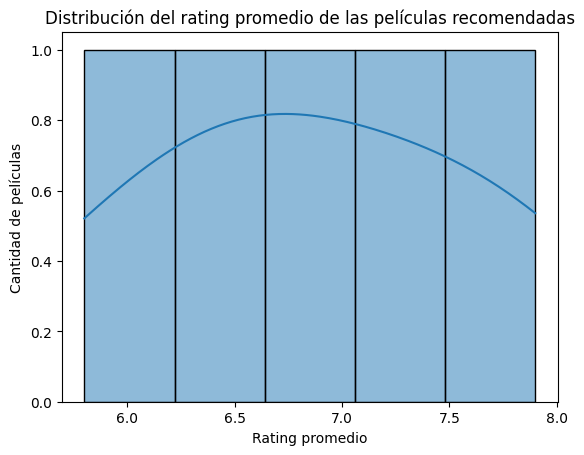

In [129]:
ratings = recs['AvgRating']
sns.histplot(ratings, bins=5, kde=True)
plt.title("Distribución del rating promedio de las películas recomendadas")
plt.xlabel("Rating promedio")
plt.ylabel("Cantidad de películas")
plt.show()


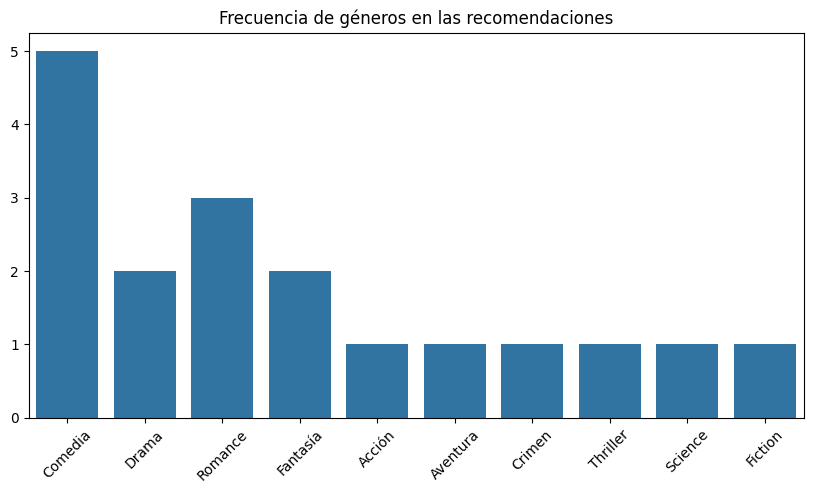

In [130]:
# Lista de géneros separados
generos = recommendations['Genres'].str.cat(sep=', ').split(', ')
generos_count = Counter(generos)

plt.figure(figsize=(10,5))
sns.barplot(x=list(generos_count.keys()), y=list(generos_count.values()))
plt.xticks(rotation=45)
plt.title("Frecuencia de géneros en las recomendaciones")
plt.show()

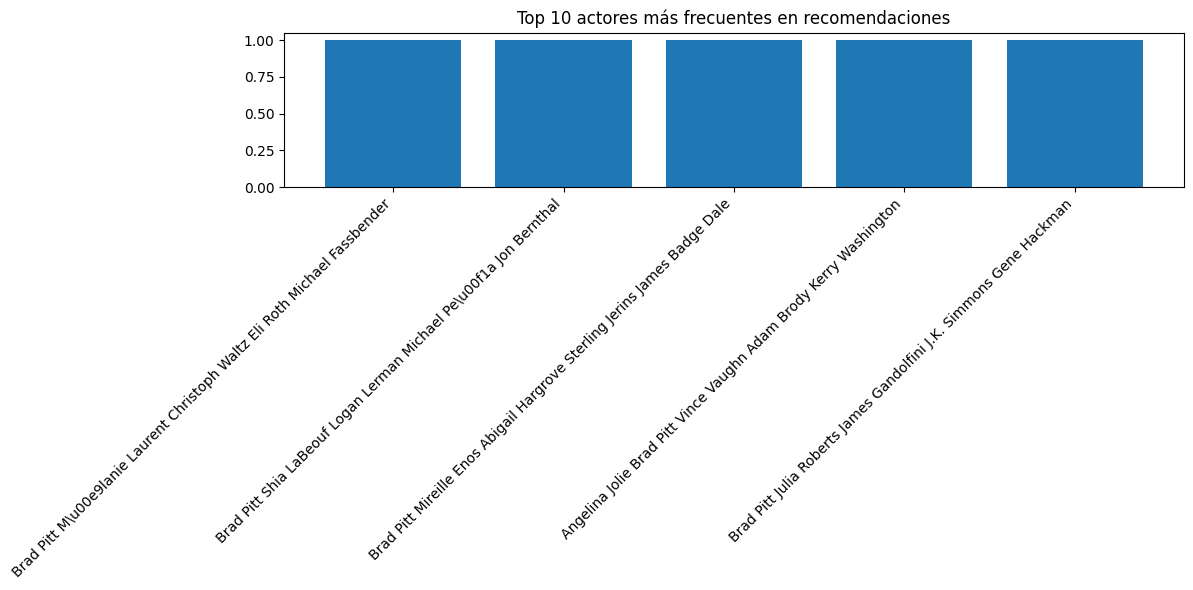

In [131]:
# Suponiendo que 'recs' es tu DataFrame de recomendaciones
actores = recs['CleanCast'].str.cat(sep=', ')  # concatenar todos los actores separados por coma
actores_lista = [a.strip() for a in actores.split(',') if a.strip() != '']

conteo_actores = Counter(actores_lista)

# Tomamos los 10 actores más frecuentes
top_actores = conteo_actores.most_common(10)

nombres = [a[0] for a in top_actores]
frecuencias = [a[1] for a in top_actores]

plt.figure(figsize=(12,6))
plt.bar(nombres, frecuencias)
plt.title("Top 10 actores más frecuentes en recomendaciones")
plt.xticks(rotation=45, ha='right')  # Rota y alinea etiquetas para mejor lectura
plt.tight_layout()  # Ajusta layout para que no se corten etiquetas
plt.show()